# Assignment 01 Notebook
**230266B - Jathunwaththa J.C.R.N.**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Question 01

In [17]:
def intensity_transform(im, breakpoints):
    # Transformation function based on the breakpoints
    transform = np.zeros(256)
    for (x1, y1), (x2, y2) in zip(breakpoints[:-1], breakpoints[1:]):
        segment = np.linspace(y1, y2, x2 - x1, endpoint=False)
        transform[x1:x2] = segment
    transform = transform.astype(np.uint8)

    # Apply the transformation to the input image
    transformed = transform[im].astype(np.uint8)

    return transformed, transform

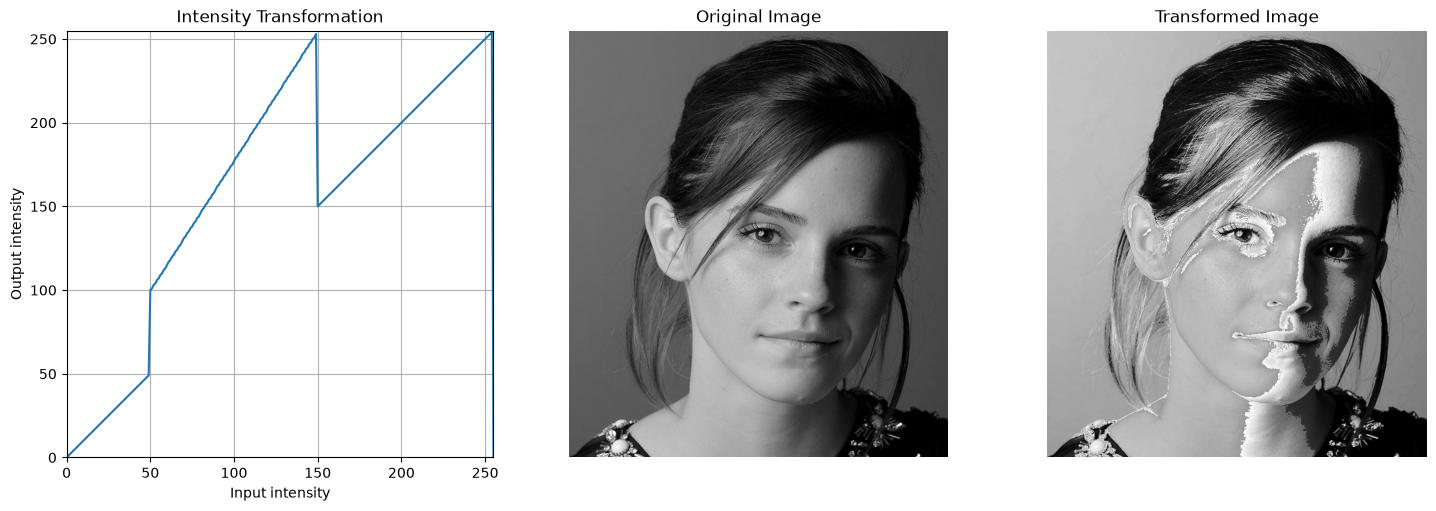

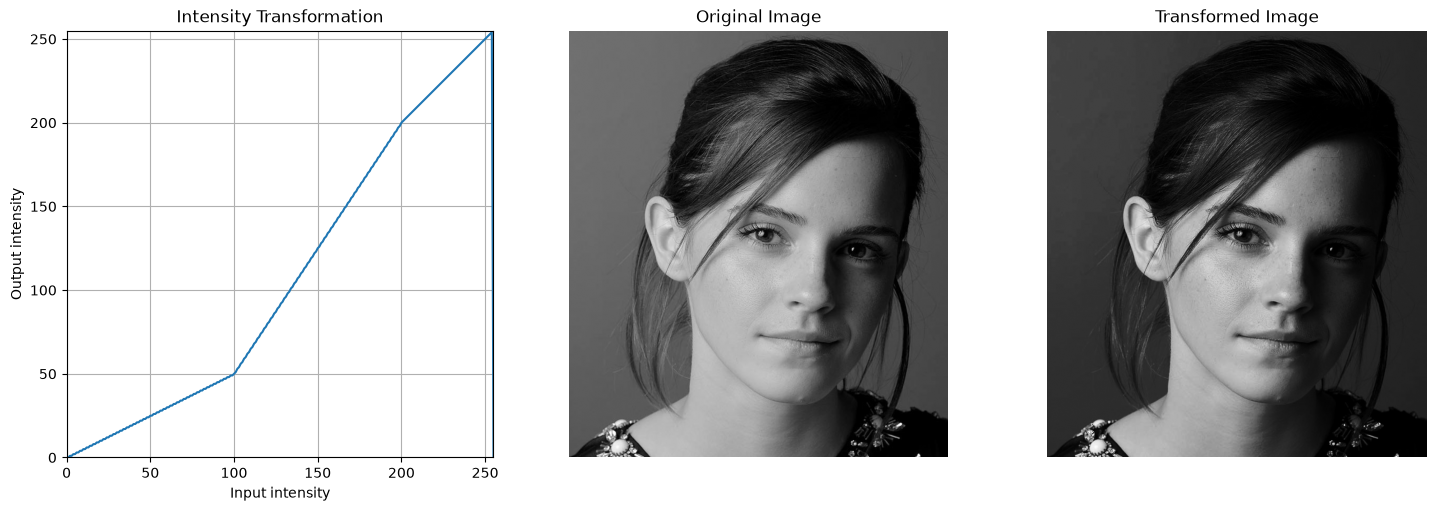

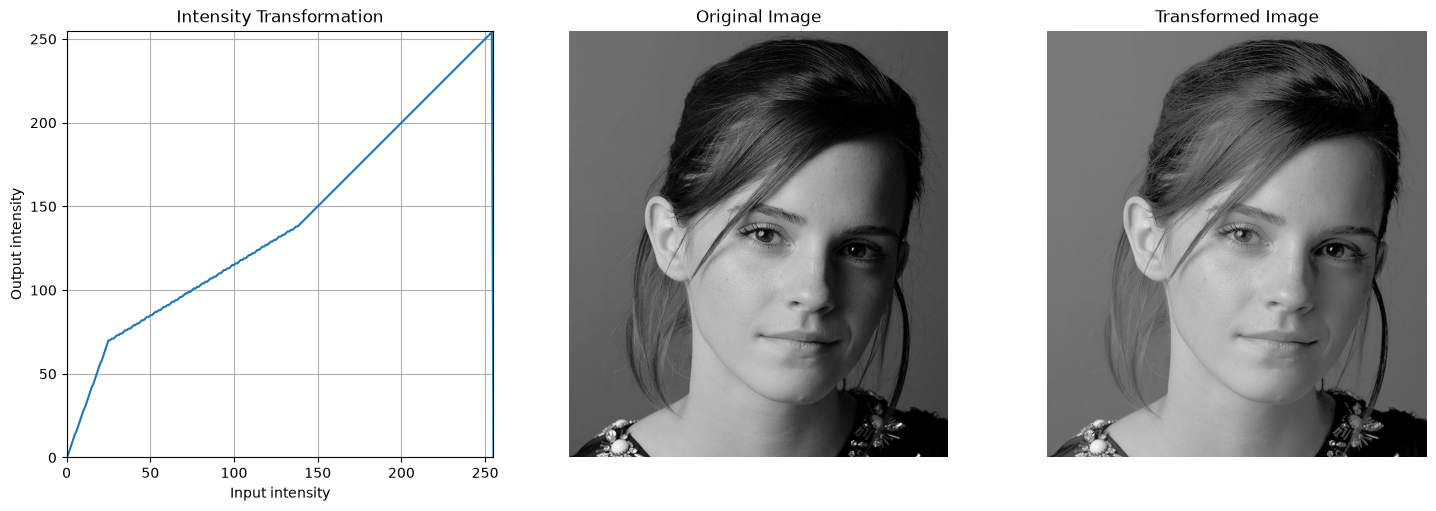

In [36]:
im = cv2.imread("../images/emma.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoints_list = [
    [(0, 0), (50, 50), (50, 100), (150, 255), (150, 150), (255, 255)],
    [(0, 0), (100, 50), (200, 200), (255, 255)],
    [(0, 0), (25, 70), (140, 140), (255, 255)]
]

for breakpoints in breakpoints_list:
    transformed_im, transform = intensity_transform(im, breakpoints)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Transformation function
    ax[0].plot(np.arange(256), transform)
    ax[0].set_xlabel("Input intensity")
    ax[0].set_ylabel("Output intensity")
    ax[0].set_title("Intensity Transformation")
    ax[0].set_xlim(0, 255)
    ax[0].set_ylim(0, 255)
    ax[0].set_aspect("equal", adjustable="box")
    ax[0].grid()

    # Original
    ax[1].imshow(im, cmap="gray")
    ax[1].set_title("Original Image")
    ax[1].axis("off")

    # Transformed
    ax[2].imshow(transformed_im, cmap="gray")
    ax[2].set_title("Transformed Image")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


### Question 02

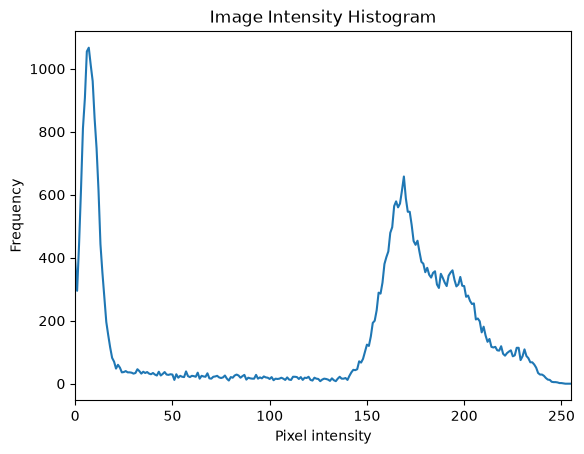

In [56]:
hist = cv2.calcHist([im], [0], None, [256], [0, 256])

plt.plot(hist)
plt.xlabel("Pixel intensity")
plt.ylabel("Frequency")
plt.title("Image Intensity Histogram")
plt.xlim(0, 255)
plt.show()

The intensity histogram shows that the meaningful brain tissues mainly occupy the intensity range from 160 to 220, while the background and non-target tissues have lower intensity values.

Contrast enhancement using piecewise linear transformation:
- Gray matter accentuation: Intensities below 160 are mapped to 0 to suppress the background, while the range [160, 180] is stretched to [0, 255] to enhance the contrast of the gray matter.
- White matter accentuation: Intensities below 180 are mapped to 0, while the range [180, 220] is stretched to [0, 255] to enhance and highlight the white matter.

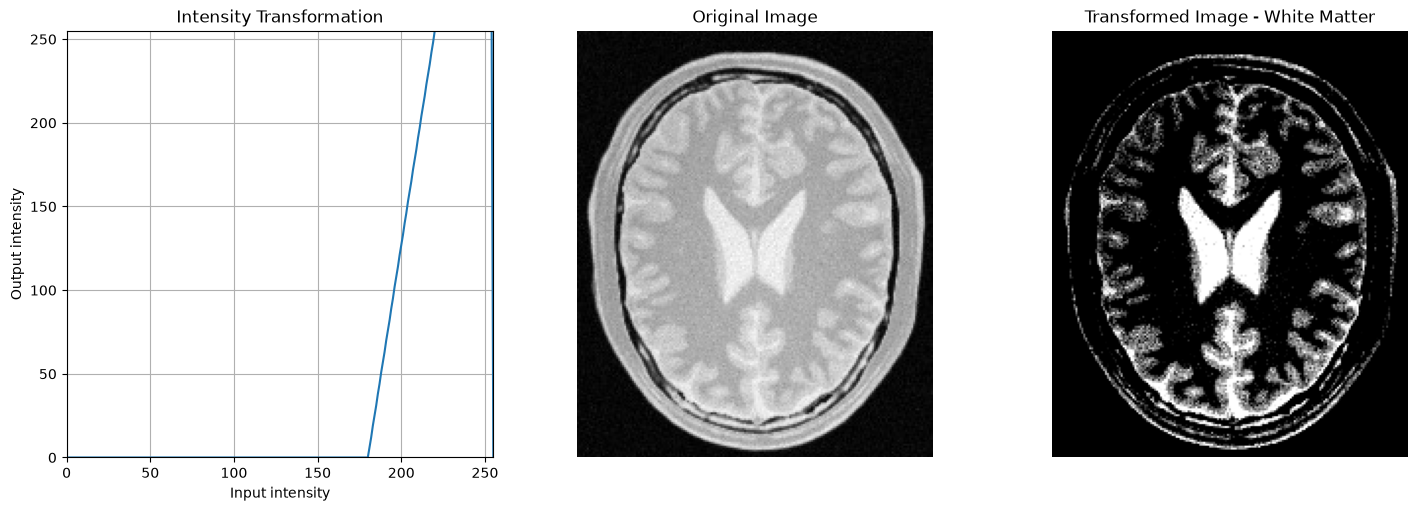

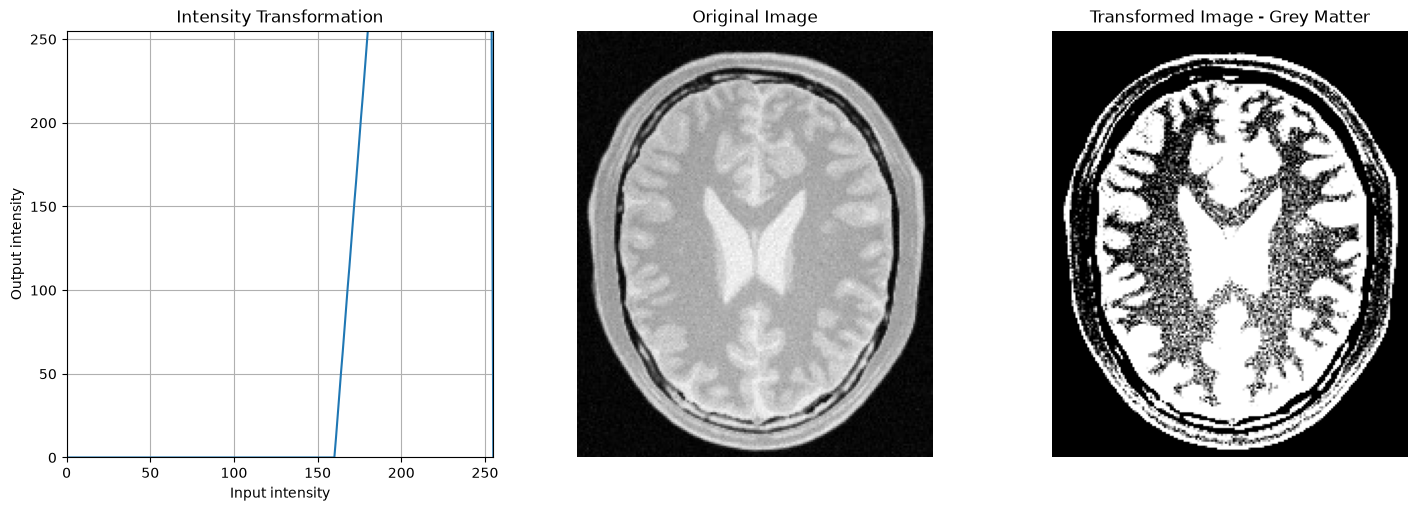

In [55]:
im = cv2.imread("../images/brain.jpeg", cv2.IMREAD_GRAYSCALE)

breakpoints_white = [
    (0,   0),
    (180, 0),
    (220, 255),
    (255, 255)
]

breakpoints_grey = [
    (0,   0),
    (160, 0),
    (180, 255),
    (255, 255)
]

topics = ["White Matter", "Grey Matter"]
breakpoints_list = [breakpoints_white, breakpoints_grey]

for topic, breakpoints in zip(topics, breakpoints_list):
    transformed_im, transform = intensity_transform(im, breakpoints)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # Transformation function
    ax[0].plot(np.arange(256), transform)
    ax[0].set_xlabel("Input intensity")
    ax[0].set_ylabel("Output intensity")
    ax[0].set_title("Intensity Transformation")
    ax[0].set_xlim(0, 255)
    ax[0].set_ylim(0, 255)
    ax[0].set_aspect("equal", adjustable="box")
    ax[0].grid()

    # Original
    ax[1].imshow(im, cmap="gray")
    ax[1].set_title("Original Image")
    ax[1].axis("off")

    # Transformed
    ax[2].imshow(transformed_im, cmap="gray")
    ax[2].set_title(f"Transformed Image - {topic}")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

### Question 03

Gamma correction is applied only to the lightness ($L^*$) channel in the $L^*a^*b^*$ color space. This changes the brightness while preserving the original color information. A gamma value of $\gamma = 0.55$ was used to brighten the darker regions of the image. As seen in the histogram, the $L^*$ values shift toward higher intensities, making details in dark areas more visible. The modified $L^*$ channel is then combined with the original $a^*$ and $b^*$ channels to produce the final image while maintaining its original colors.


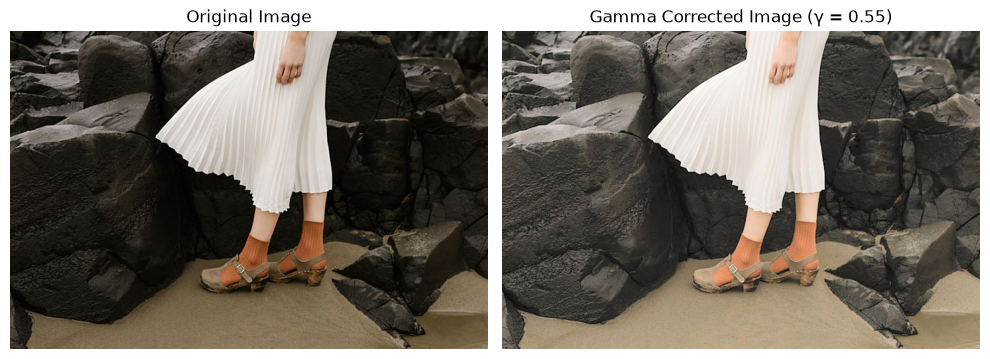

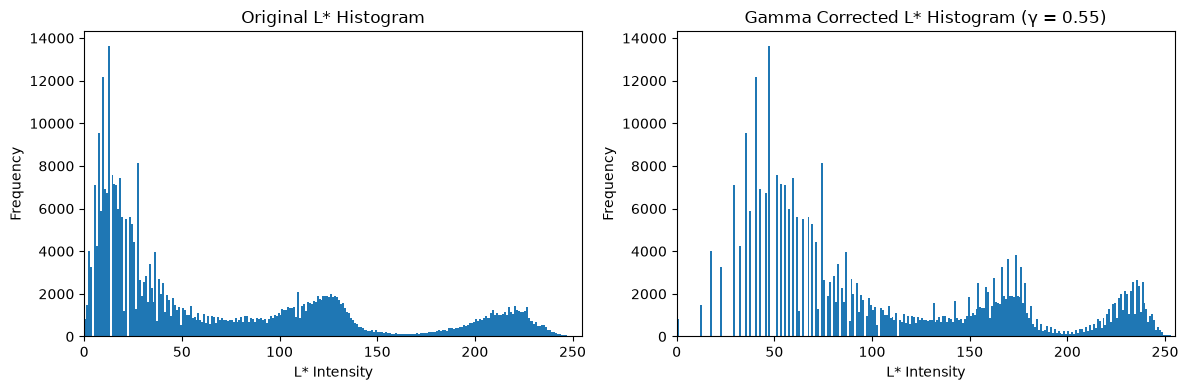

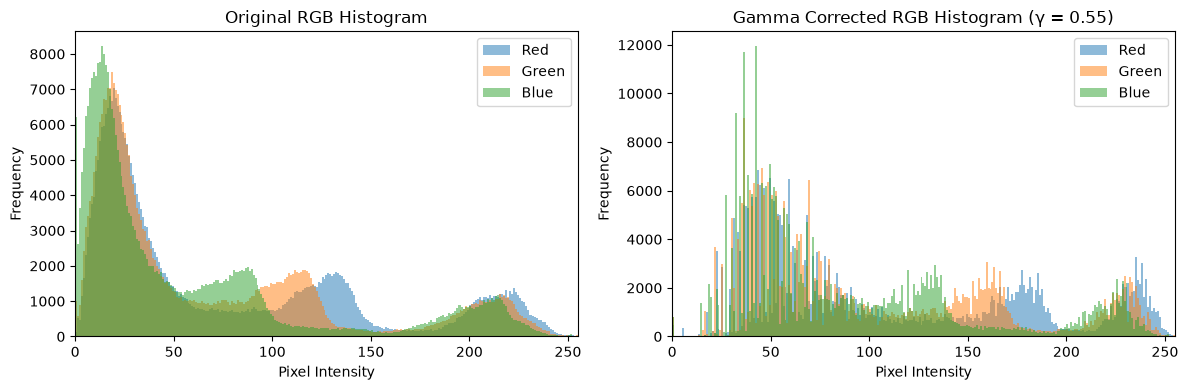

In [64]:
im = cv2.imread('../images/skirt.jpeg')

# Convert to Lab
lab = cv2.cvtColor(im, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)

# Gamma correction
gamma = 0.55
L_gamma = np.power(L / 255.0, gamma) * 255.0

# Reconstruct image
lab_gamma = cv2.merge((L_gamma.astype(np.uint8), a, b))
im_gamma = cv2.cvtColor(lab_gamma, cv2.COLOR_LAB2BGR)

# Plot images
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Image", fontsize=12)
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(im_gamma, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Gamma Corrected Image (γ = {gamma})", fontsize=12)
ax[1].axis("off")

plt.tight_layout()
plt.show()

# Plot L* histograms for original and gamma corrected images
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(L.ravel(), bins=256, range=(0, 256))
ax[0].set_title("Original L* Histogram", fontsize=12)
ax[0].set_xlabel("L* Intensity")
ax[0].set_ylabel("Frequency")
ax[0].set_xlim(0, 255)

ax[1].hist(L_gamma.ravel(), bins=256, range=(0, 256))
ax[1].set_title(f"Gamma Corrected L* Histogram (γ = {gamma})", fontsize=12)
ax[1].set_xlabel("L* Intensity")
ax[1].set_ylabel("Frequency")
ax[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

# Plot RGB histograms for original and gamma corrected images
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for channel, name in enumerate(["Red", "Green", "Blue"]):
    ax[0].hist(
        cv2.cvtColor(im, cv2.COLOR_BGR2RGB)[:, :, channel].ravel(),
        bins=256,
        range=(0, 256),
        alpha=0.5,
        label=name
    )

    ax[1].hist(
        cv2.cvtColor(im_gamma, cv2.COLOR_BGR2RGB)[:, :, channel].ravel(),
        bins=256,
        range=(0, 256),
        alpha=0.5,
        label=name
    )

ax[0].set_title("Original RGB Histogram", fontsize=12)
ax[1].set_title(f"Gamma Corrected RGB Histogram (γ = {gamma})", fontsize=12)

for a in ax:
    a.set_xlabel("Pixel Intensity")
    a.set_ylabel("Frequency")
    a.set_xlim(0, 255)
    a.legend()

plt.tight_layout()
plt.show()

### Question 04

The parameter $a$ controls the strength of the vibrance enhancement. Increasing $a$ produces more vivid colors, while decreasing $a$ results in a weaker enhancement. A value of $a = 0.7$ was selected as it provides a noticeable increase in vibrance without making the colors appear overly strong.


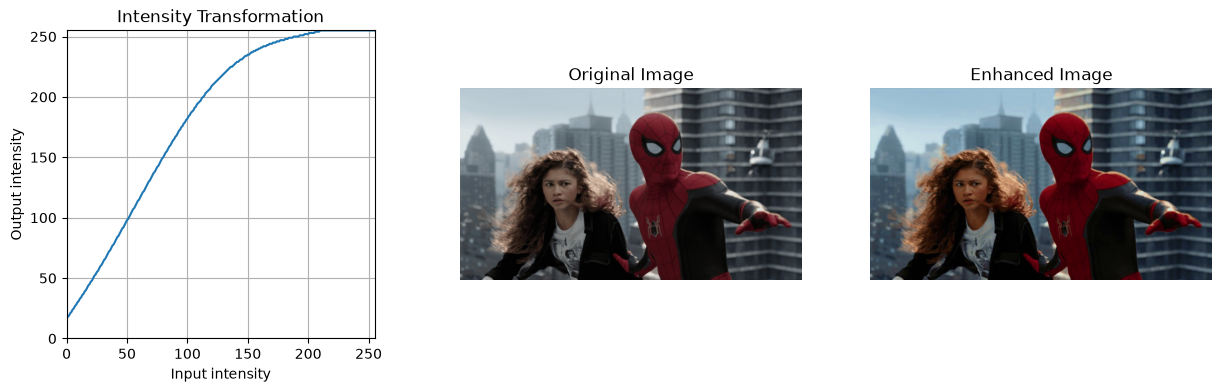

In [76]:
im = cv2.imread('../images/spiderman.jpeg')

# Convert the image to HSV color space and split the channels
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Define parameters for the enhancement
a = 0.7
sigma = 70

# Apply the enhancement to the saturation channel
x = np.arange(256, dtype=np.float32)
transform = np.clip(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 0, 255).astype(np.uint8)
s_new = cv2.LUT(s, transform)
hsv_new = cv2.merge([h, s_new, v])
im_new = cv2.cvtColor(hsv_new, cv2.COLOR_HSV2BGR)

# Display the intensity transformation, the original and enhanced images
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(np.arange(256), transform)
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_title("Intensity Transformation")
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_aspect("equal", adjustable="box")
axes[0].grid()

axes[1].imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
axes[1].set_title('Original Image')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(im_new, cv2.COLOR_BGR2RGB))
axes[2].set_title('Enhanced Image')
axes[2].axis('off')
plt.show()


### Question 05

The original image has a narrow intensity range from 13 to 83, resulting in low contrast. After histogram equalization, the intensity values are spread over a much wider range, improving the contrast and making details more visible. The equalized histogram is more distributed across the available intensity range, although it is not perfectly uniform.


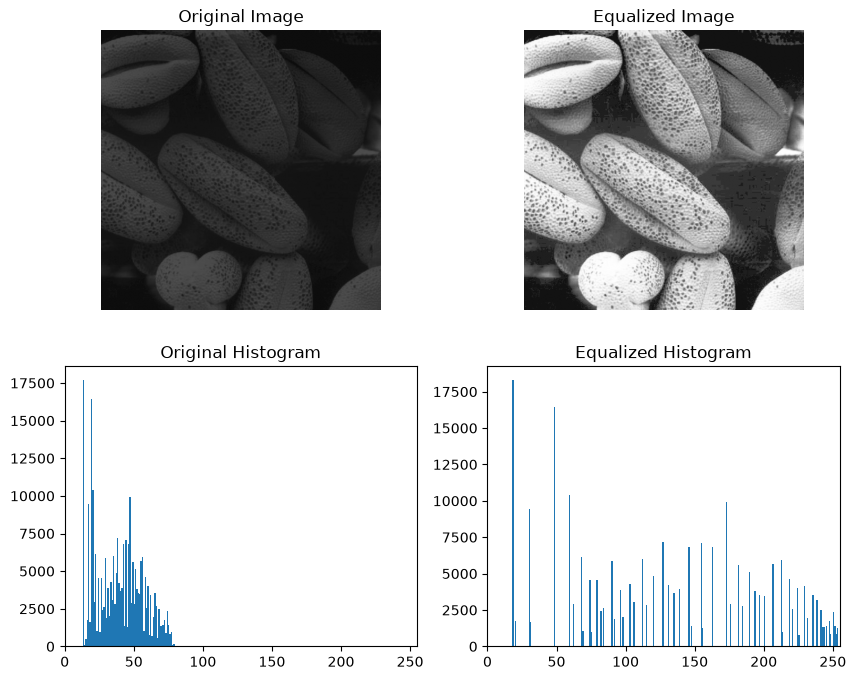

In [94]:
def histogram_equalization(im):
    # Compute the histogram of the grayscale image
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = hist.cumsum()
    # Normalize the cumulative distribution function (CDF) to the range [0, 255]
    t = np.array(255 * cdf / cdf[-1], dtype=np.uint8)
    return t[im]

im = cv2.imread("../images/shells.tif", cv2.IMREAD_GRAYSCALE)
equalized_im = histogram_equalization(im)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(im, vmin=0, vmax=255, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(equalized_im, vmin=0, vmax=255, cmap='gray')
axes[0, 1].set_title('Equalized Image')
axes[0, 1].axis('off')

axes[1, 0].hist(im.ravel(), bins=257, range=(0, 256))
axes[1, 0].set_xlim(0, 255)
axes[1, 0].set_title('Original Histogram')

axes[1, 1].hist(equalized_im.ravel(), bins=257, range=(0, 256))
axes[1, 1].set_xlim(0, 255)
axes[1, 1].set_title('Equalized Histogram')

plt.show()

### Question 06

The original image has a narrow intensity range from 13 to 83, resulting in low contrast. After histogram equalization, the intensity values are spread over a much wider range, improving the contrast and making details more visible. The equalized histogram is more distributed across the available intensity range, although it is not perfectly uniform.
